In [1]:
suppressPackageStartupMessages({
  library(dplyr)
  library(tidyr)
  library(ggplot2)
  library(ggrepel)
  library(ggpubr)
})

In [2]:
# Function to create correlation plot
plot_pathway_correlation <- function(file_path, comparison_name, point_color) {
  
  df <- read.csv(file_path)
  
  # Filter to progenitor cell types and selected pathways
  prog_df <- df %>% 
    filter(celltype %in% progenitor_celltypes) %>%
    filter(pathway %in% pathways)
  
  # Pivot to wide format for correlation
  nes_wide <- prog_df %>%
    group_by(celltype, pathway) %>%
    summarize(NES = mean(NES), .groups = "drop") %>% 
    pivot_wider(names_from = pathway, values_from = NES)
  
  # Compute correlation for subtitle
  cor_result <- cor.test(nes_wide$`DNA REPAIR`, nes_wide$`CELL CYCLE`, method = "pearson")
  cor_label <- sprintf("R = %.2f, p = %.2g", cor_result$estimate, cor_result$p.value)
  
  # Create plot
  plot <- ggplot(nes_wide, aes(x = `DNA REPAIR`, y = `CELL CYCLE`)) +
    geom_point(size = 2, alpha = 0.7, color = point_color) +
    geom_text_repel(aes(label = celltype), size = 5, max.overlaps = 10, 
                    force = 1.5, show.legend = FALSE) +
    geom_smooth(method = "lm", se = TRUE, color = point_color, fill = point_color, linewidth = 1, alpha = 0.2) +
    labs(
      x = "DNA REPAIR NES",
      y = "CELL CYCLE NES",
      title = paste("NES Correlation - ", comparison_name),
      subtitle = cor_label
    ) +
    theme_classic(base_size = 16) +
    theme(
      axis.title = element_text(face = "bold"),
      plot.title = element_text(face = "bold", hjust = 0.5),
      plot.subtitle = element_text(hjust = 0.5),
      panel.grid = element_blank()
    )
  
  # Display the plot
  print(plot)
  
  # Return the filtered data frame
  return(prog_df)
}

In [3]:
# Define progenitor cell types (constant across all comparisons)
progenitor_celltypes <- c(
  "Pre B Heavy", "Pre B Prolif", "Pre B Light",
  "Pre Mono Prolif", "Pre Mono Core", "Pre Prog Ery",
  "CMP Core", "CMP Gran", "CLP", "LMPP", "MEP",
  "Prog DC cDC", "Prog DC pDC", "Prog Ery", "Prog Ery Prolif",
  "Prog B Pre", "Prog B", "HSPC Multi", "HSPC Stem"
)

# Pathways to correlate
pathways <- c('DNA REPAIR', 'CELL CYCLE')

In [4]:
comparisons <- list(
  list(suffix = "PreTx_vs_Healthy",   name = "PreTx vs Healthy",   color = "#8B0000"),
  list(suffix = "EI_vs_Healthy",      name = "EI vs Healthy",      color = "#7502C2"),
  list(suffix = "ASCT90d_vs_Healthy", name = "ASCT90d vs Healthy", color = "#2346DE"),
  list(suffix = "ASCT1y_vs_Healthy", name = "ASCT1y vs Healthy", color = "#038AFF"),
  list(suffix = "ASCT2y_vs_Healthy", name = "ASCT2y vs Healthy", color = "#008080")
    
)

base_path <- "../../data/figure-inputs/l3-fgsea_all_results"

options(repr.plot.width = 7, repr.plot.height = 5)

pdf("../../data/figure-outputs/supplementary-4/sup_4d.pdf", width = 7, height = 5)
plots <- lapply(comparisons, function(comp) {
  file_path <- file.path(base_path, paste0("fgsea_all_results_bmmc_", comp$suffix, ".csv"))
  plot_pathway_correlation(file_path, comp$name, comp$color)
})

dev.off()

`geom_smooth()` using formula = 'y ~ x'


`geom_smooth()` using formula = 'y ~ x'


`geom_smooth()` using formula = 'y ~ x'


`geom_smooth()` using formula = 'y ~ x'


`geom_smooth()` using formula = 'y ~ x'


pdf 
  2

> Results

`geom_smooth()` using formula = 'y ~ x'


`geom_smooth()` using formula = 'y ~ x'


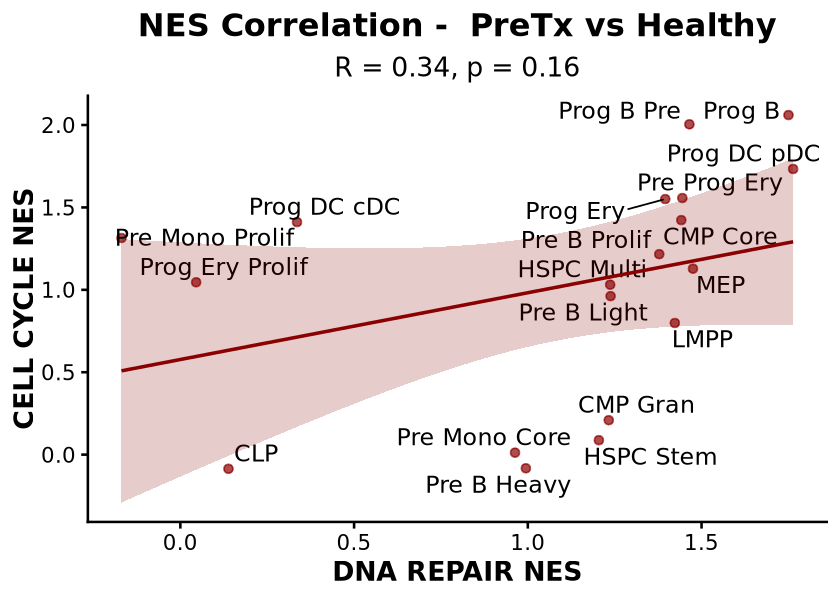

`geom_smooth()` using formula = 'y ~ x'


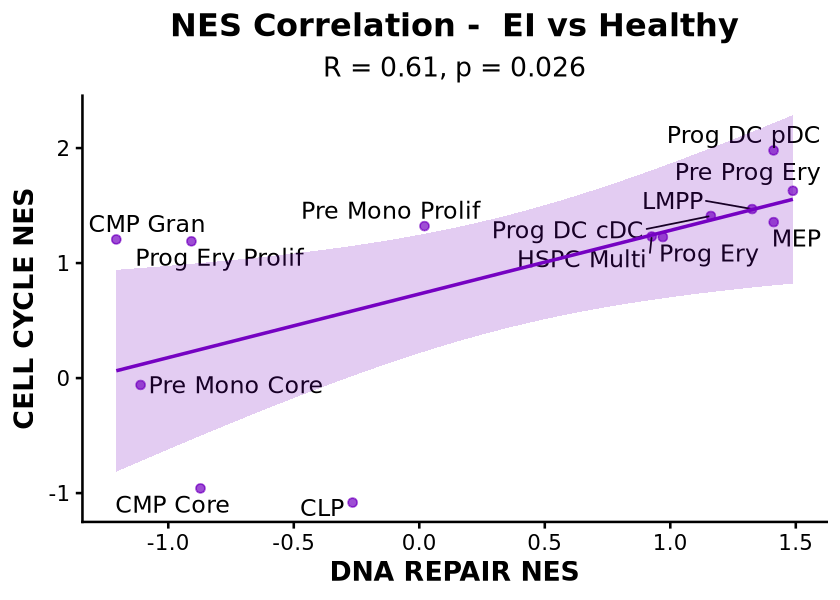

`geom_smooth()` using formula = 'y ~ x'


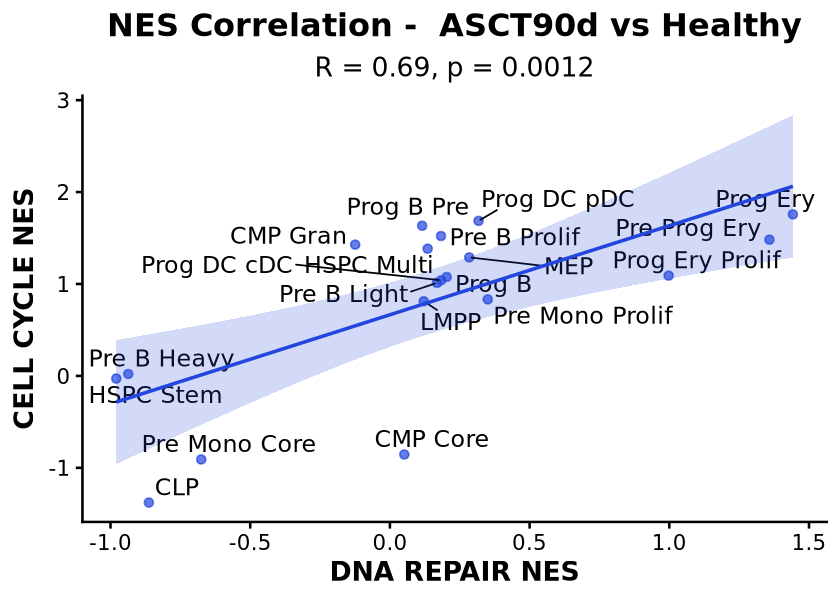

`geom_smooth()` using formula = 'y ~ x'


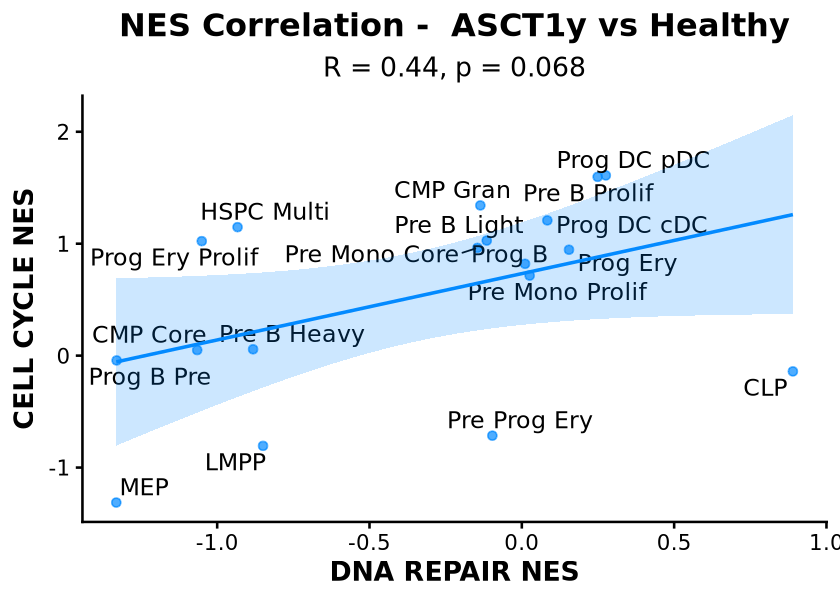

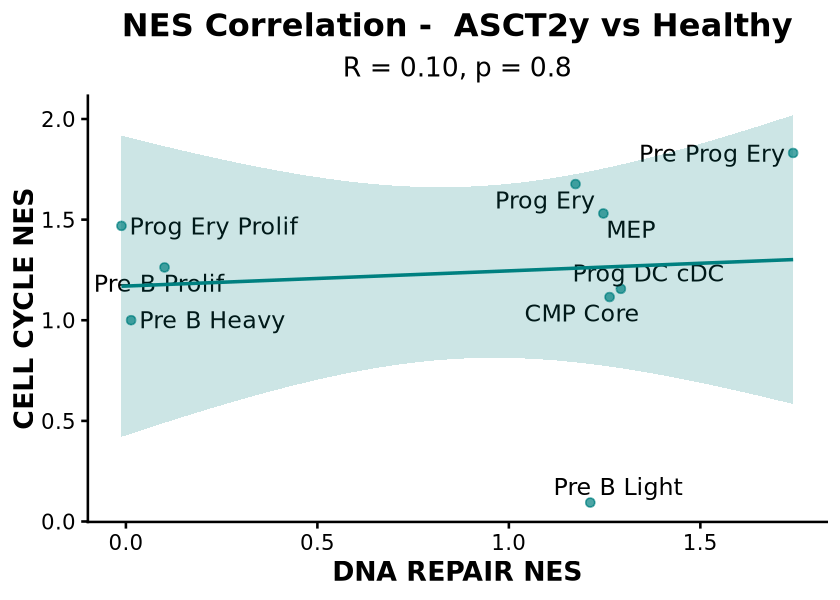

In [5]:
plots <- lapply(comparisons, function(comp) {
  file_path <- file.path(base_path, paste0("fgsea_all_results_bmmc_", comp$suffix, ".csv"))
  plot_pathway_correlation(file_path, comp$name, comp$color)
})